In [1]:
import sys
from pathlib import Path

# 当前 notebook 在 examples/ 下，把项目根目录加进来
sys.path.append(str(Path.cwd().parent))


Transfit-V0.4

1：生成一条超新星光变曲线

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import transfit as tf

Initializing and JIT-compiling the model...
Model is ready for fast execution.


Text(0, 0.5, 'Bolometric Luminosity (erg/s)')

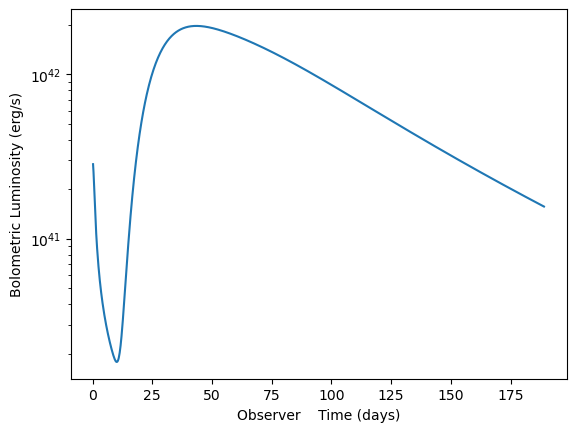

In [3]:
##热光变曲线
ctx = tf.Context(
    distance=tf.Distance(z=0.05)
)
theta = (5, 1.0, 1.0, 0.2, 100.0, 0.5, 0.2, 0.03) #模型参数
#M_ej, v_ej, E_Th_in, M_Ni, R_max_in, x_s, kappa0, kappa_gamma
bol = tf.lightcurve_bol(model="scni", theta=theta, ctx=ctx, Nx=100, Ny=1000, t_max_days=180.0)

plt.plot(bol.t_days, bol.Lbol)
plt.yscale("log")
plt.xlabel("Observer    Time (days)")
plt.ylabel("Bolometric Luminosity (erg/s)")

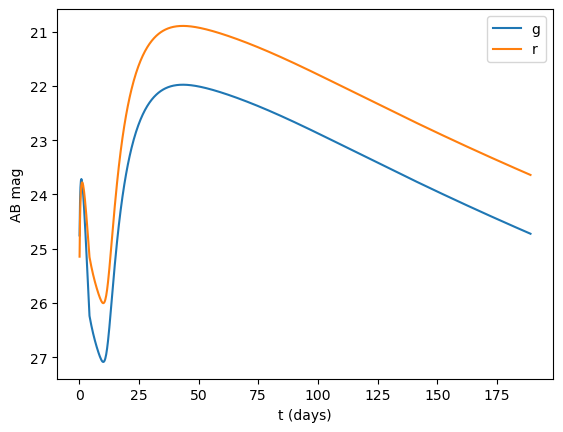

In [4]:
##多波段光变曲线

import numpy as np


# Nickel 参数顺序：
# (M_ej, v_ej, E_Th_in, M_Ni, R_max_in, x_s, kappa0, kappa_gamma, T_floor)
theta = (5, 1.0, 1.0, 0.2, 100.0, 0.5, 0.2, 0.03, 4000.0) #模型参数
# band -> nu_eff (Hz) 
filters = {"g": 6.2e14, "r": 4.8e14}

ctx = tf.Context(
    distance=tf.Distance(z=0.05, DL_cm=1.0e27),  # forward 示例直接给 DL_cm
    filters=filters,
    y_kind="mag",  # "mag" -> AB magnitude；如果想要 Fnu 就改成 "flux"
)

# 计算 multi-band 网格曲线
mb = tf.lightcurve_multiband(
    model="scNi",
    theta=theta,
    ctx=ctx,
    bands=["g", "r"],
    Nx=100, Ny=1000, t_max_days=180.0,
)



# 画图：星等越小越亮，所以反转y轴
plt.figure()
plt.plot(mb.t_days, mb.y["g"], label="g")
plt.plot(mb.t_days, mb.y["r"], label="r")
plt.gca().invert_yaxis()
plt.xlabel("t (days)")
plt.ylabel("AB mag")
plt.legend()
plt.show()


2：拟合数据

In [5]:
###热光变拟合
data_bol = np.loadtxt("./data/sn1993j_lbol.txt")  # 读取数据文件

t=data_bol[:, 0]  # 时间，单位：天
t=t - t.min()  # 转换为相对于首次观测的时间
Lbol=data_bol[:, 1]  # 光变曲线，单位：erg/s
Lbol_err=data_bol[:, 2]  # 误差，单位：erg

data_bol_tf = tf.BolometricData(
    t_days=t,
    y=Lbol,
    yerr=Lbol_err,
) 


In [6]:
# filters = {"B": 6.8e14, "V": 5.5e14, "R": 4.7e14, "I": 3.9e14}  # 滤波器参数
# ctx = tf.Context(distance=tf.Distance(z=0.001728), filters=filters, y_kind="mag")  #组装cxt



# # res = tf.fit_multiband(
# #     data=data,
# #     model="ni",
# #     ctx=ctx,
# #     sampler_kwargs=dict(
# #         nwalkers=40, nsteps=5000, burnin=300, thin=10,
# #         seed=123, progress=True,
# #     ),
# #     model_kwargs=dict(Nx=100, Ny=1000, t_max_days=float(np.max(data.t_days) + 50))
# # )

res_bol = tf.fit_bol(
    data=data_bol_tf,
    model="scni",
    ctx=ctx,
    priors={
        "M_ej": (1, 5),
        "v_ej": (0.3, 3.0),
        "M_Ni": (0.01, 0.5)
    },
    fixed={"kappa0": 0.1},
    sampler_kwargs=dict(
        nwalkers=40, nsteps=5000, burnin=300, thin=10,
        seed=123, progress=True,
    ),
    model_kwargs=dict(Nx=100, Ny=1000, t_max_days=float(np.max(data_bol_tf.t_days) + 50))
)   ##可以自定义先验范围和固定参数


100%|██████████| 5000/5000 [02:53<00:00, 28.89it/s]


In [7]:
# path = tf.save(res_bol,path="mcmc_out/fit_scni_test.npz") 
# res_bol_loaded = tf.load("mcmc_out/fit_scni_test.npz")

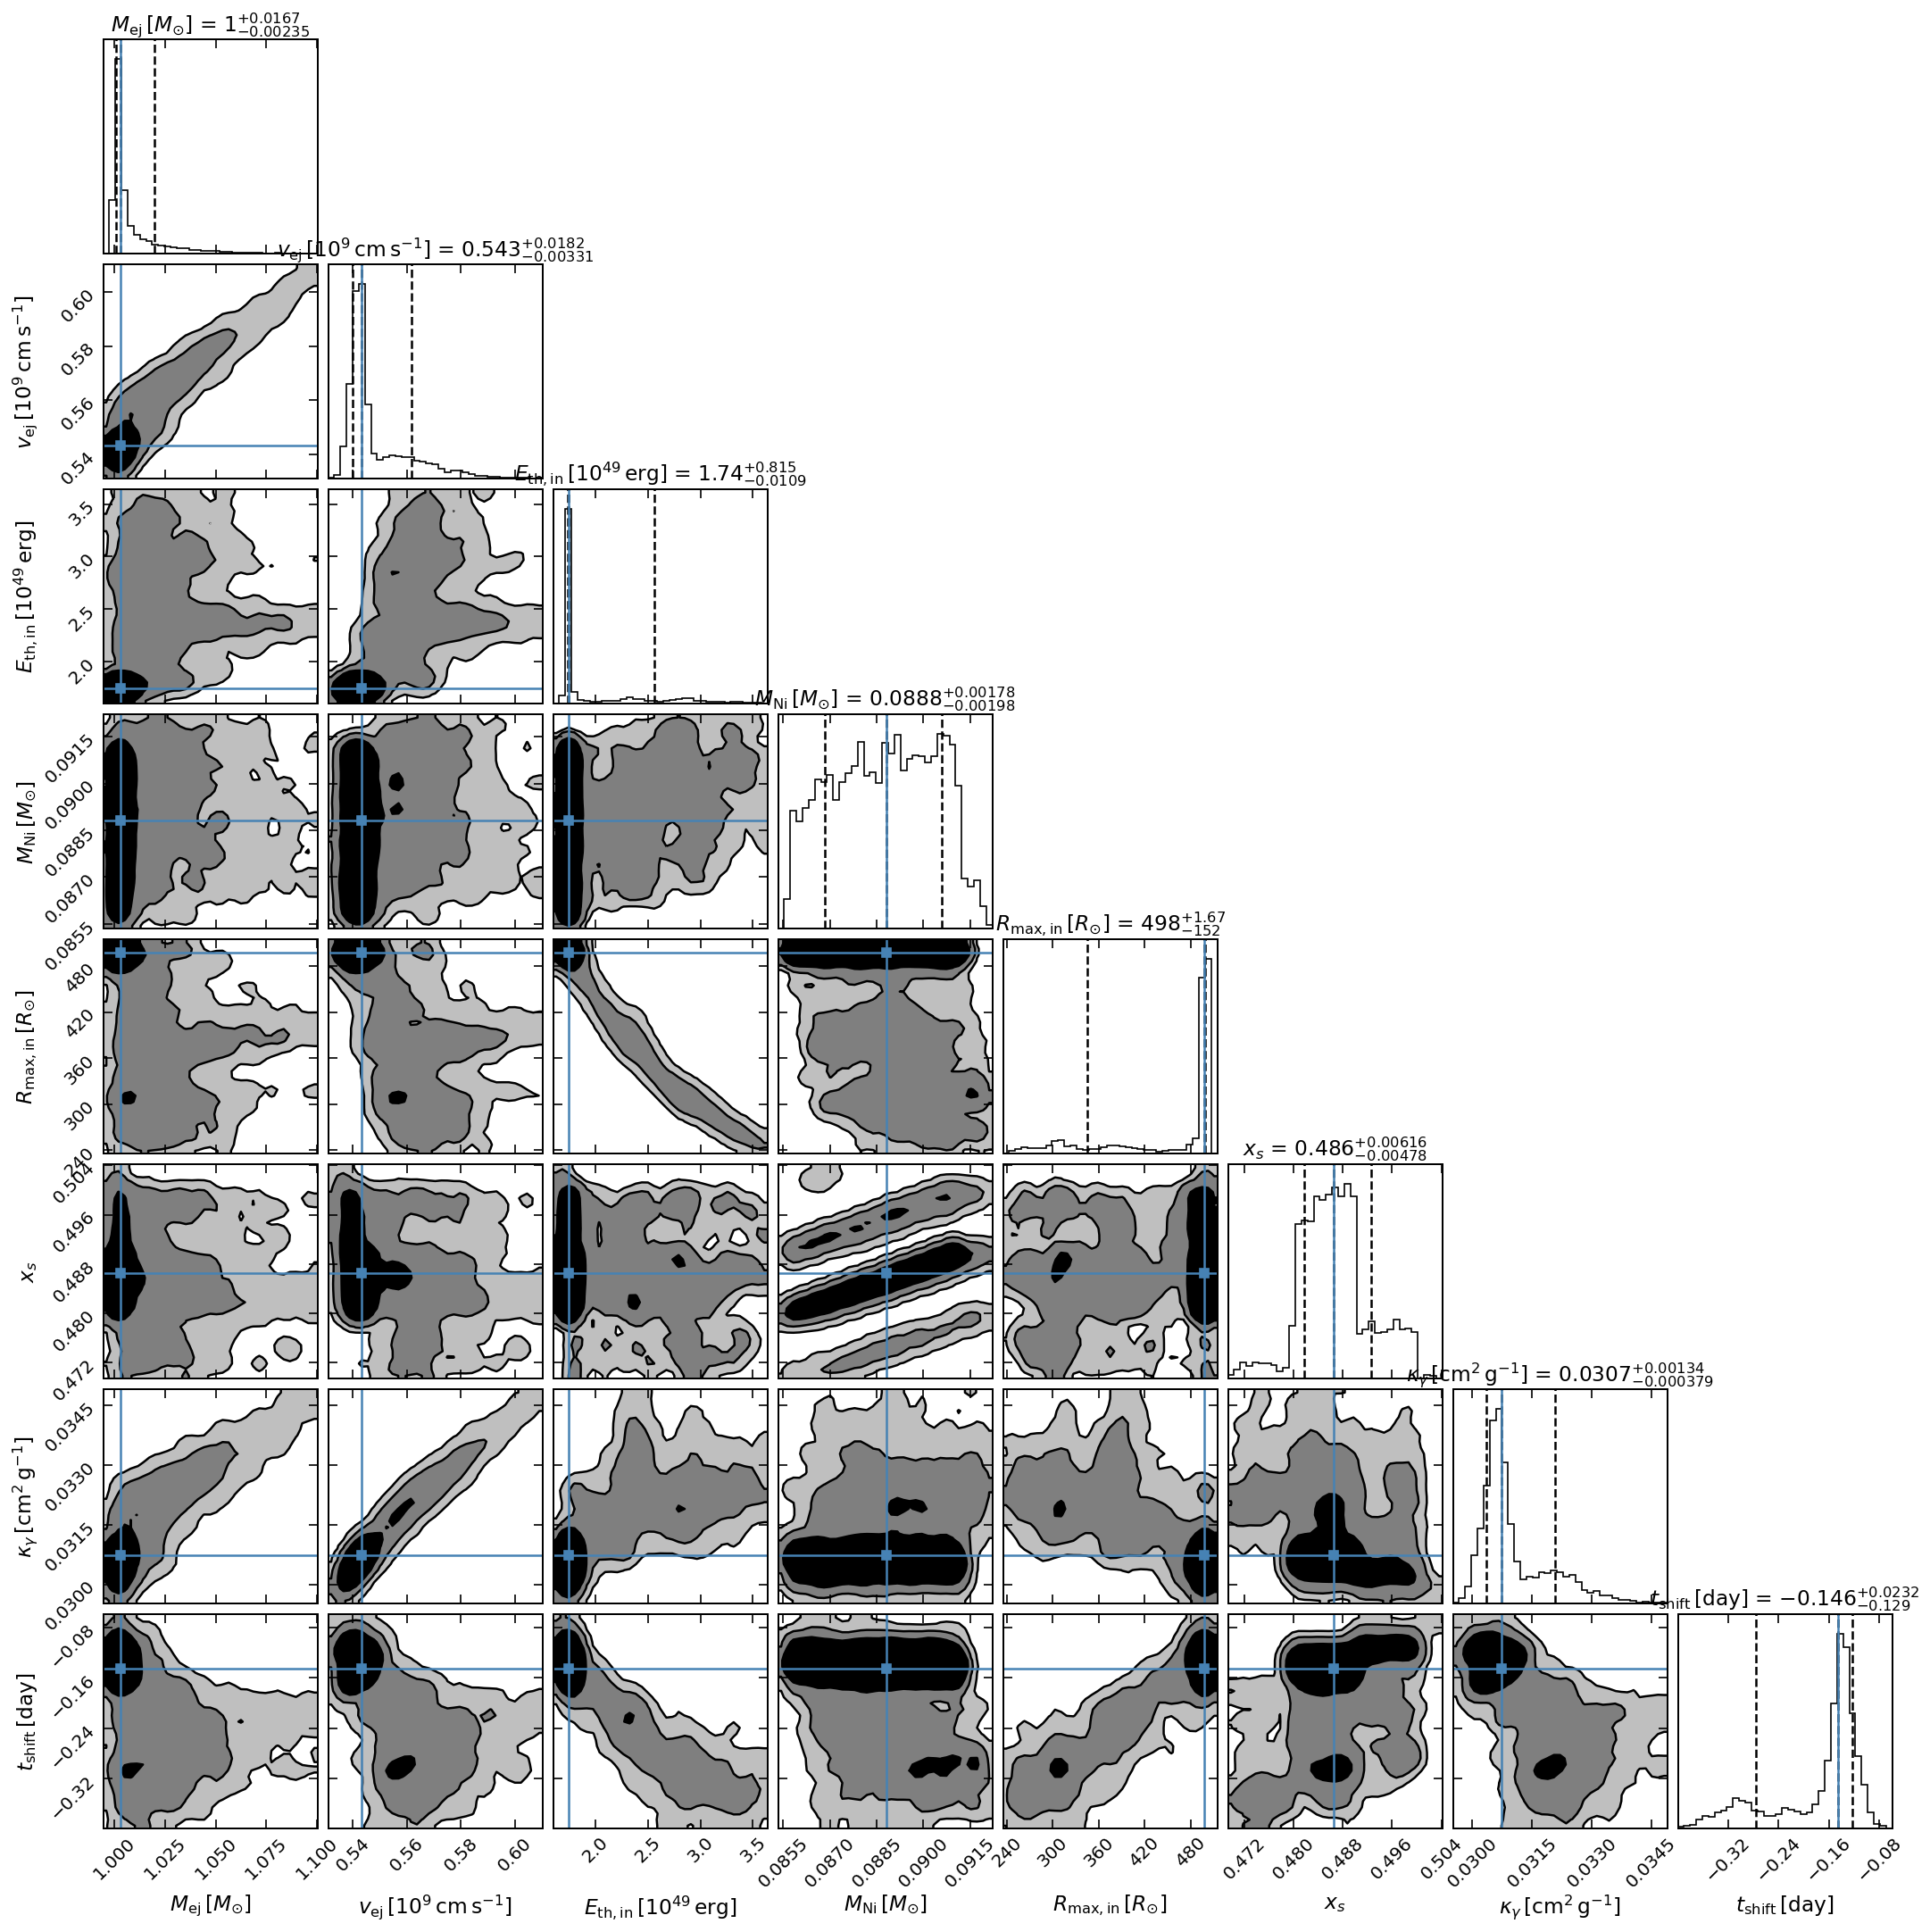

In [8]:
tf.plot.corner(res_bol)

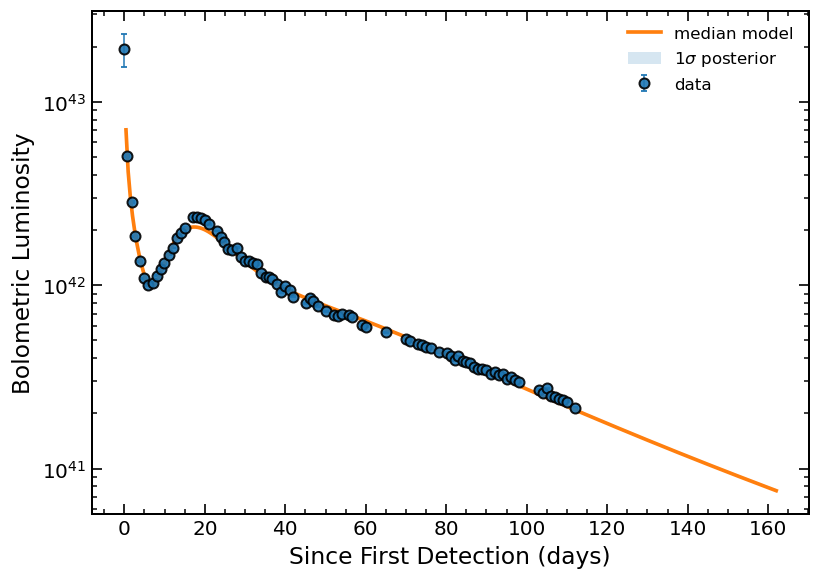

In [9]:
tf.plot.fit_bol(res_bol, data=data_bol_tf,show_1sigma=True) 


In [10]:
###多波段拟合

###观测数据读取和储存

import pandas as pd
import importlib
import transfit.priors

importlib.reload(transfit.priors)
importlib.reload(transfit)


csv_path = r"./data/sn2007gr.csv"   # 改成你的文件路径

df = pd.read_csv(csv_path)

# 用 JD 做时间（你的表里 JD 是 245xxxx.x）
t0 = float(np.nanmin(df["JD"].to_numpy(float)))
df["t_days"] = df["JD"].to_numpy(float) - t0

# 把宽表转成长表：每个 band 一行
band_map = [
    ("B", "Bmag", "e_Bmag"),
    ("V", "Vmag", "e_Vmag"),
    ("R", "Rmag", "e_Rmag"),
    ("I", "Imag", "e_Imag"),
]

rows = []
for b, mcol, ecol in band_map:
    if mcol not in df.columns or ecol not in df.columns:
        continue
    m = pd.to_numeric(df[mcol], errors="coerce").to_numpy(float)
    e = pd.to_numeric(df[ecol], errors="coerce").to_numpy(float)

    ok = np.isfinite(df["t_days"].to_numpy(float)) & np.isfinite(m) & np.isfinite(e) & (e > 0)
    if not np.any(ok):
        continue

    rows.append(
        pd.DataFrame(
            {
                "t_days": df.loc[ok, "t_days"].to_numpy(float),
                "band": np.full(np.sum(ok), b, dtype=object),
                "mag": m[ok],
                "emag": e[ok],
            }
        )
    )

lc = pd.concat(rows, ignore_index=True).sort_values("t_days").reset_index(drop=True)
lc = lc[lc["t_days"] <100].reset_index(drop=True)


data = tf.MultiBandData(
    t_days=lc["t_days"].to_numpy(float),
    band=lc["band"].to_numpy(),
    y=lc["mag"].to_numpy(float),
    yerr=lc["emag"].to_numpy(float),
)    ####最后组装成这种格式




In [11]:


# 观测数据（你已有 data: MultiBandData）
# ctx
filters = {"B": 6.8e14, "V": 5.5e14, "R": 4.7e14, "I": 3.9e14}  # 滤波器参数
ctx = tf.Context(distance=tf.Distance(z=0.001728), filters=filters, y_kind="mag")  #组装cxt



# res = tf.fit_multiband(
#     data=data,
#     model="ni",
#     ctx=ctx,
#     sampler_kwargs=dict(
#         nwalkers=40, nsteps=5000, burnin=300, thin=10,
#         seed=123, progress=True,
#     ),
#     model_kwargs=dict(Nx=100, Ny=1000, t_max_days=float(np.max(data.t_days) + 50))
# )

res = tf.fit_multiband(
    data=data,
    model="ni",
    ctx=ctx,
    priors={
        "M_ej": (1, 5),
        "v_ej": (0.3, 3.0),
        "M_Ni": (0.01, 0.5),
        "T_floor": (3000, 8000),
    },
    fixed={"kappa0": 0.1},
    sampler_kwargs=dict(
        nwalkers=40, nsteps=5000, burnin=300, thin=10,
        seed=123, progress=True,
    ),
    model_kwargs=dict(Nx=100, Ny=1000, t_max_days=float(np.max(data.t_days) + 50))
)   ##可以自定义先验范围和固定参数


Initializing and JIT-compiling the model...
Model is ready for fast execution.


100%|██████████| 5000/5000 [03:36<00:00, 23.14it/s]


In [12]:
# 保存和加载结果
# path = tf.save(res,path="mcmc_out/fit_ni_test.npz") 
# res = tf.load("mcmc_out/fit_ni_test.npz")

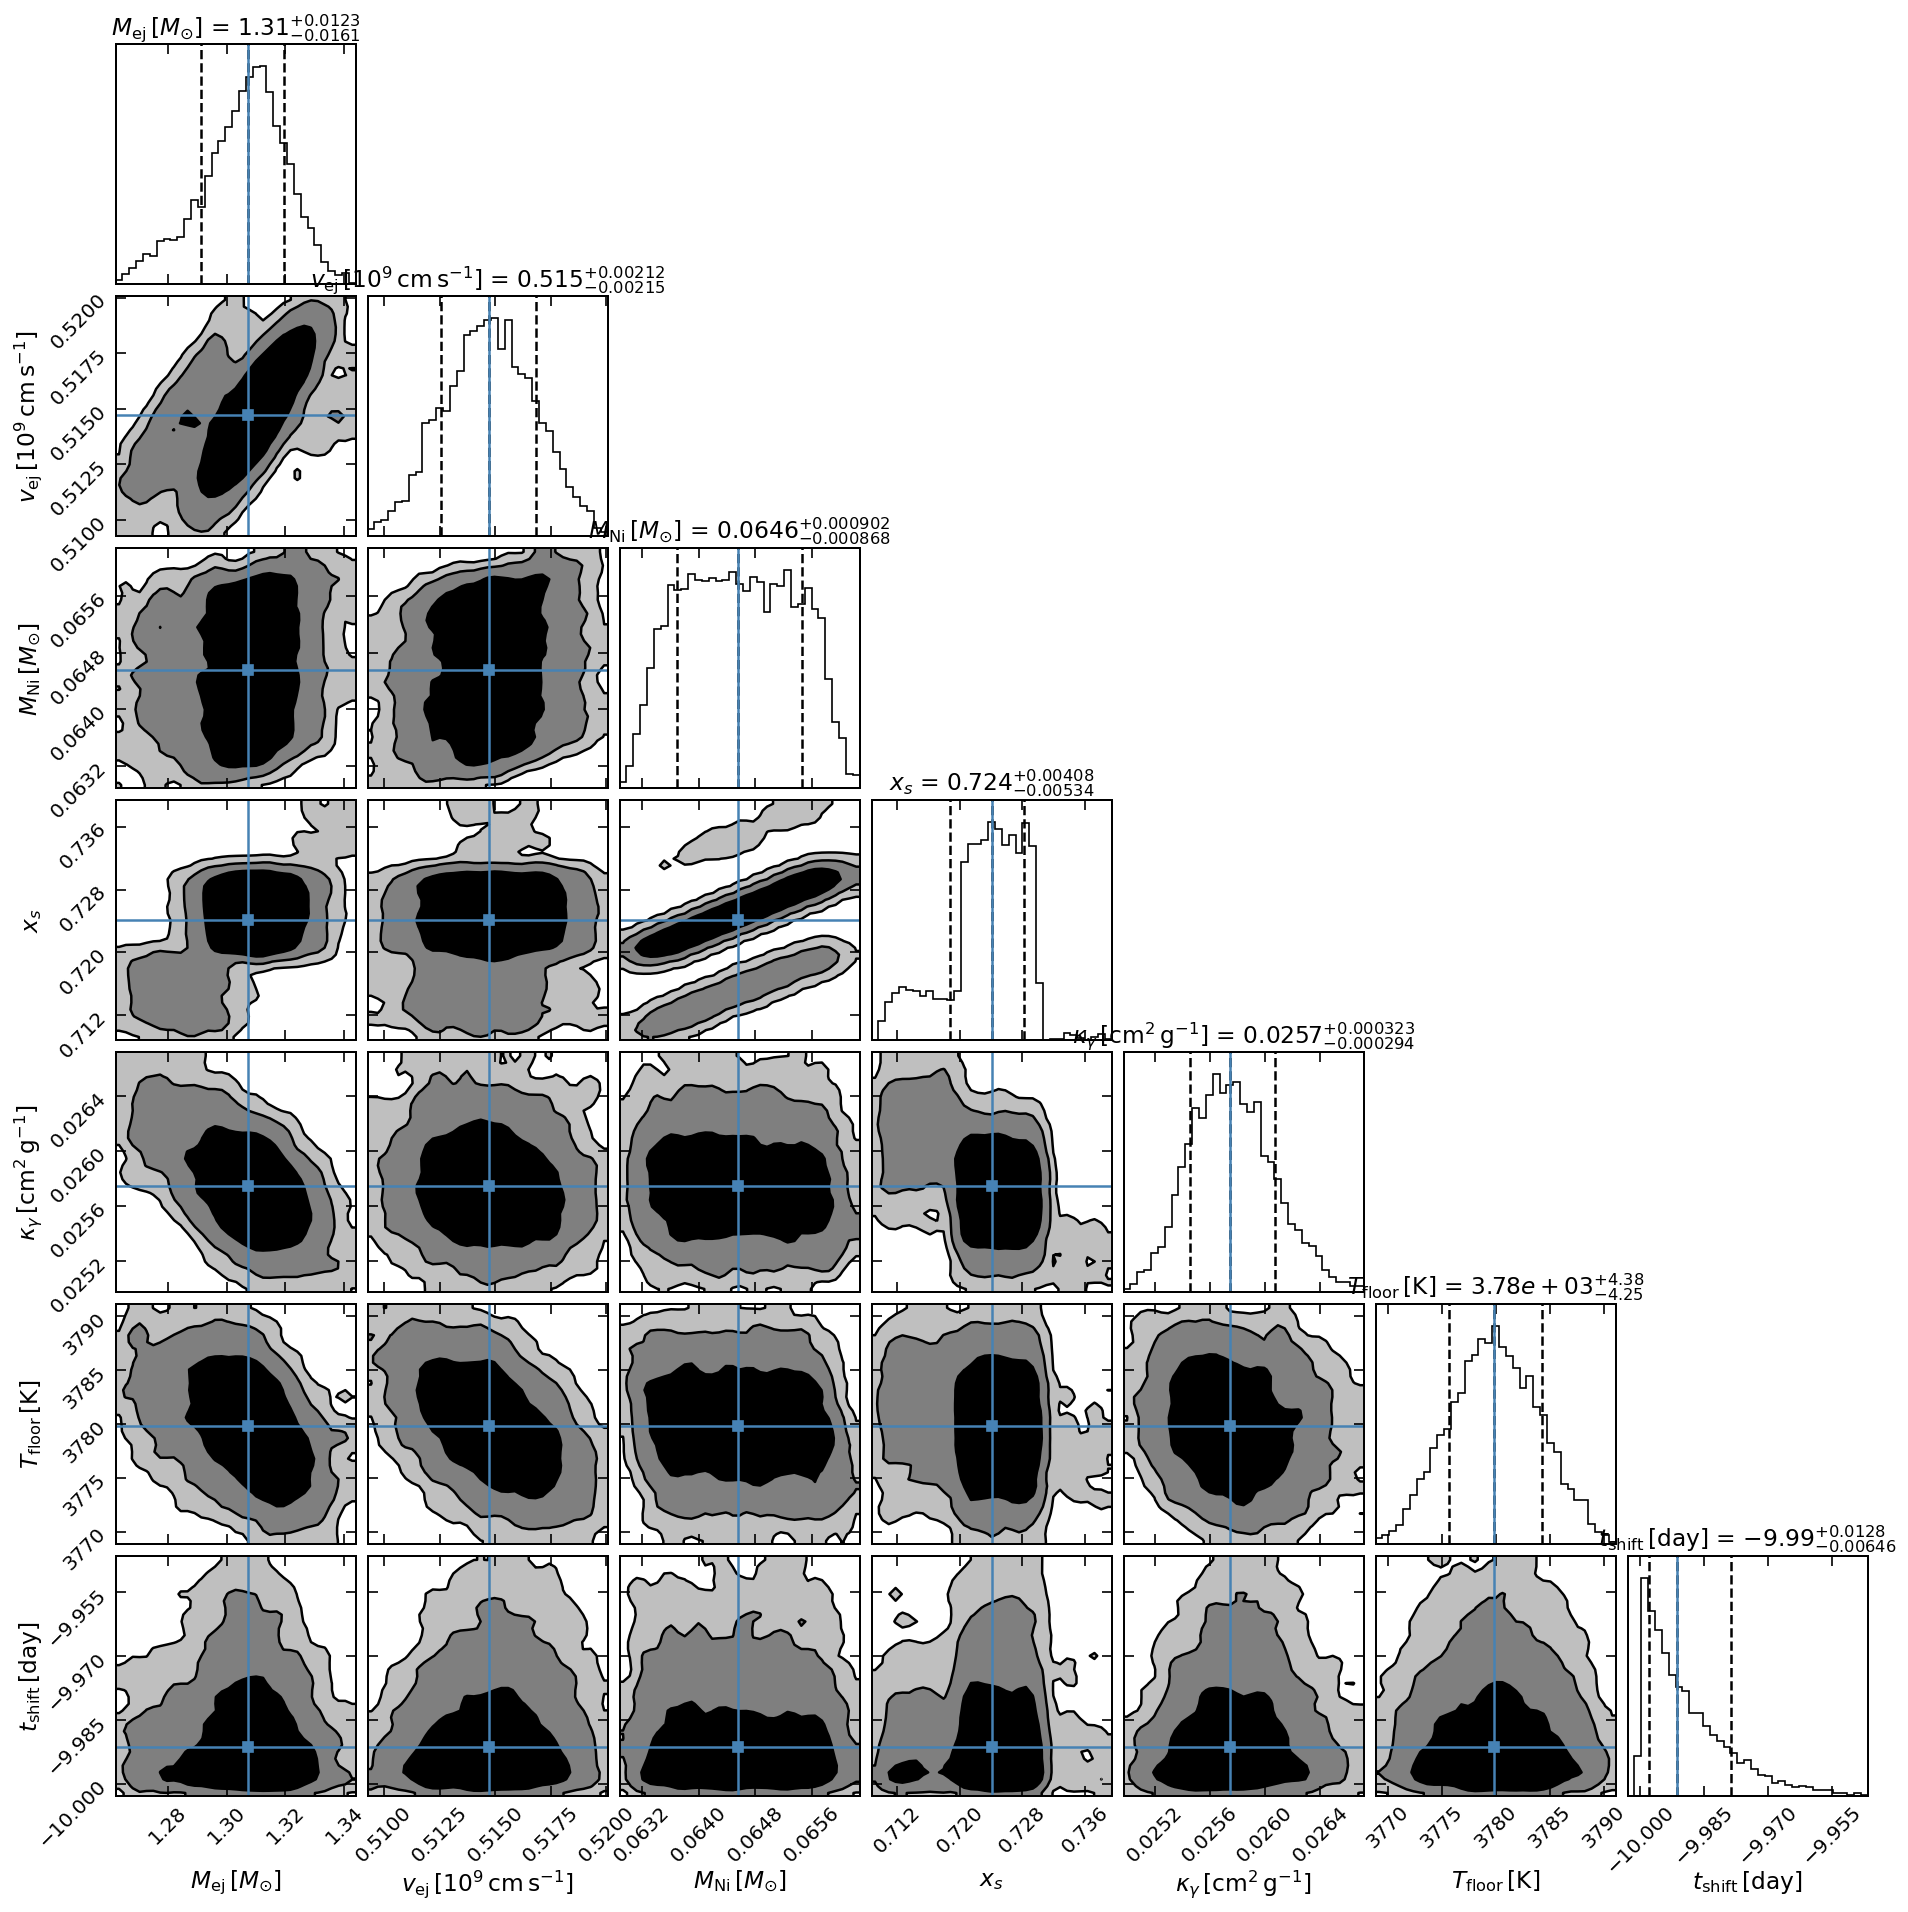

In [13]:
#一键画图
tf.plot.corner(res)

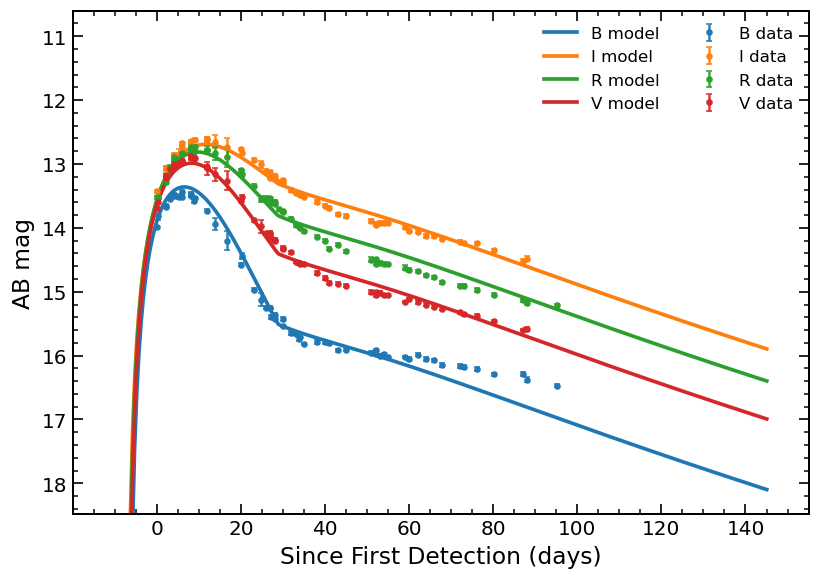

In [14]:
tf.plot.fit_multiband(res, data=data,show_1sigma=True) 

## Log Prior Tutorial (in `priors`)

Log priors are now passed inside `priors` (no separate `priors_log10` argument).

Supported formats per parameter:
- `(lo, hi)` for linear uniform prior
- `("log10", lo_log10, hi_log10)` for log-uniform prior in log10 bounds
- `{"bounds": (lo, hi), "scale": "linear"|"log10"}`

Example meaning:
- `"M_Ni": ("log10", -2.5, -0.3)` means `M_Ni` is sampled in `[10^-2.5, 10^-0.3]` with log-uniform prior.


In [15]:
# Example 1: bolometric fit with mixed linear + log priors
# res_bol_log = tf.fit_bol(
#     data=data_bol_tf,
#     model="scni",
#     ctx=ctx,
#     priors={
#         "M_ej": (1.0, 5.0),
#         "v_ej": (0.3, 3.0),
#         "M_Ni": ("log10", -2.5, -0.3),
#         "kappa_gamma": ("log10", -3.0, -1.0),
#     },
#     fixed={"kappa0": 0.1},
#     sampler="emcee",
#     sampler_kwargs=dict(nwalkers=40, nsteps=2000, burnin=300, thin=5, seed=123),
# )

# Example 2: multiband fit with log prior on M_Ni
# res_mb_log = tf.fit_multiband(
#     data=data,
#     model="ni",
#     ctx=ctx,
#     priors={
#         "M_ej": (1.0, 5.0),
#         "v_ej": (0.3, 3.0),
#         "T_floor": (3000, 8000),
#         "M_Ni": ("log10", -2.5, -0.3),
#     },
#     fixed={"kappa0": 0.1},
#     sampler="dynesty",
#     sampler_kwargs=dict(nlive=200, dlogz=0.1, seed=123),
# )


## Best-Fit Parameters in `res`

After fitting, you can directly read best-fit parameters from `res`.

- `res.best_params` or `res.best_fit_params`: full best-fit parameter dict
- `res.best_log_prob`: best log-probability
- `res.best_fit`: full record including index/params/sample


In [16]:
# Example (assuming you already have `res` or `res_bol`)
# best_params = res.best_params
# print(best_params)

# print("best log_prob:", res.best_log_prob)
# print(res.best_fit)
